In [1]:
# Consolidated imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [2]:
# Load data
sparcs = pd.read_csv("data_csv/SPARCS_by_borough_2010-2024.csv")
acs = pd.read_csv("data_csv/ACS_socioeconomic_indicators_2010-2024_Data.csv")

# Standardize join keys — lowercase for safe merging
sparcs['Borough'] = sparcs['Borough'].str.strip().str.title()
acs['borough'] = acs['borough'].str.strip().str.title()

# Merge on Year + Borough
merged = sparcs.merge(
    acs[['year', 'borough', 'total_population']],
    left_on=['Year', 'Borough'],
    right_on=['year', 'borough'],
    how='left'
)

# Calculate asthma incidence rate per 100k
merged['asthma_incidence_rate'] = (
    merged['Asthma_Cases'] / merged['total_population']
) * 100_000

# Drop redundant columns from merge
merged = merged.drop(columns=['year', 'borough'])

merged = merged[['Year', 'Borough', 'Asthma_Cases', 'total_population', 'asthma_incidence_rate']]

merged.to_csv("data_csv/merged_asthma_data.csv", index=False)

In [3]:
# Prepare borough-level dataframe and plotting color map for combined control chart
# `m_borough` provides Year, Borough, and asthma incidence for plotting and control limits
m_borough = merged[["Year", "Borough", "asthma_incidence_rate"]].copy()

# Ordered list of boroughs
boroughs = sorted(m_borough["Borough"].unique())

# Color map for plotting (keeps same colors as prior scatter)
color_map = {
    'Bronx': 'tomato',
    'Brooklyn': 'steelblue',
    'Manhattan': 'green',
    'Queens': 'purple',
    'Staten Island': 'orange'
}

In [4]:
# Load data
asthma = pd.read_csv("data_csv/merged_asthma_data.csv")
nyccas = pd.read_csv("data_csv/NYCCAS-Yearly-Borough.csv")

# Standardize join keys
asthma['Borough'] = asthma['Borough'].str.strip().str.title()
nyccas['Borough'] = nyccas['Borough'].str.strip().str.title()
nyccas.rename(columns={'year': 'Year'}, inplace=True)

# Merge
merged = asthma.merge(nyccas, on=['Year', 'Borough'], how='inner')
print(f"Merged shape: {merged.shape}")
print(merged.head())

Merged shape: (23, 6)
   Year    Borough  Asthma_Cases  total_population  asthma_incidence_rate  \
0  2019      Bronx          5164         1418207.0             364.121740   
1  2019  Manhattan          1562         1628706.0              95.904356   
2  2019     Queens          2203         2253858.0              97.743514   
3  2020      Bronx          2772               NaN                    NaN   
4  2020   Brooklyn          1730               NaN                    NaN   

       Value  
0  16.358190  
1  12.800775  
2   7.360308  
3  10.284048  
4   9.552288  


In [5]:
asthma

,Year,Borough,Asthma_Cases,total_population,asthma_incidence_rate
0,2010,Bronx,9295,1386657.0,670.317173
1,2010,Brooklyn,7717,2508340.0,307.653667
2,2010,Manhattan,3769,1586698.0,237.537326
3,2010,Queens,4660,2233841.0,208.609297
4,2010,Staten Island,932,469363.0,198.566994
...,...,...,...,...,...
70,2024,Bronx,4112,1384724.0,296.954483
71,2024,Brooklyn,2478,2617631.0,94.665749
72,2024,Manhattan,1384,1660664.0,83.340158
73,2024,Queens,2123,2316841.0,91.633392


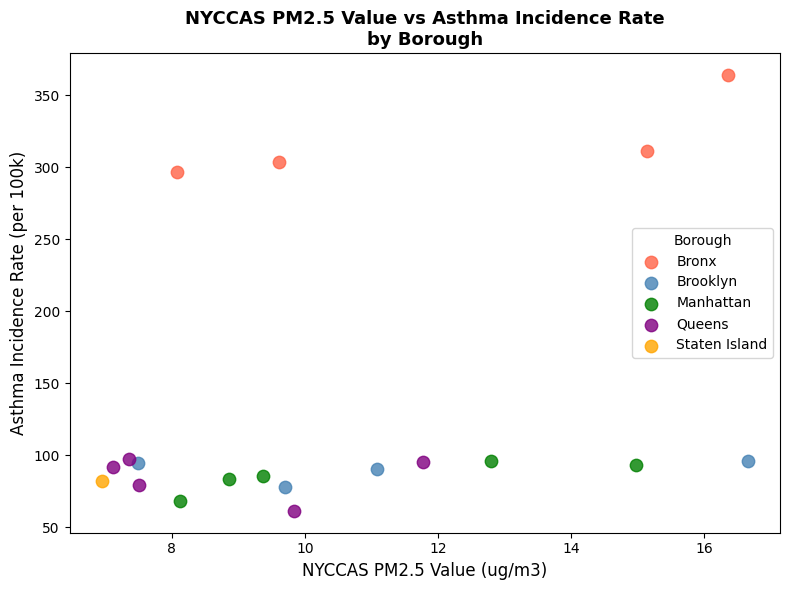

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = {'Bronx': 'tomato', 'Brooklyn': 'steelblue', 'Manhattan': 'green',
          'Queens': 'purple', 'Staten Island': 'orange'}

for borough, group in merged.groupby('Borough'):
    ax.scatter(group['Value'], group['asthma_incidence_rate'],
               label=borough, color=colors.get(borough, 'gray'),
               s=80, alpha=0.8)

ax.set_xlabel('NYCCAS PM2.5 Value (ug/m3)', fontsize=12)
ax.set_ylabel('Asthma Incidence Rate (per 100k)', fontsize=12)
ax.set_title('NYCCAS PM2.5 Value vs Asthma Incidence Rate\nby Borough', fontsize=13, fontweight='bold')
ax.legend(title='Borough')
plt.tight_layout()
plt.show()

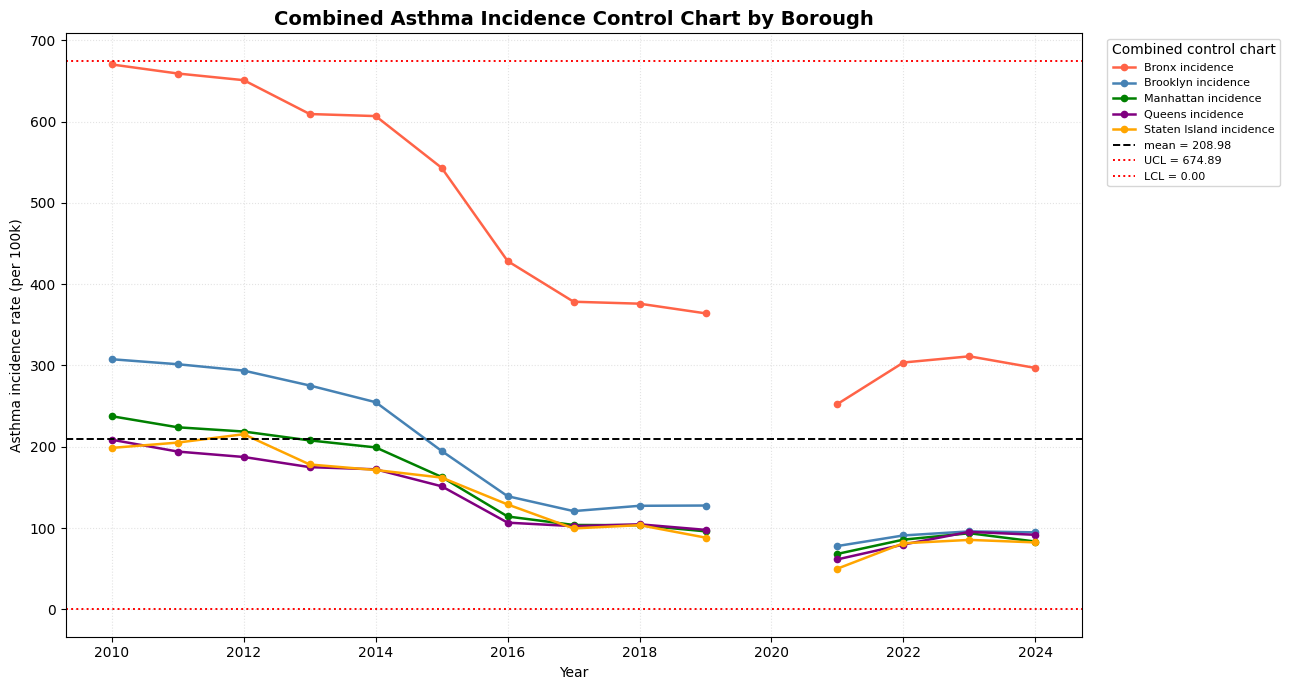

In [7]:
combined_mean = m_borough["asthma_incidence_rate"].mean()
combined_std = m_borough["asthma_incidence_rate"].std(ddof=1)
combined_ucl = combined_mean + 3 * combined_std
combined_lcl = max(combined_mean - 3 * combined_std, 0)

fig, ax = plt.subplots(figsize=(13, 7))

for borough in boroughs:
    b_data = m_borough[m_borough["Borough"] == borough].sort_values("Year")
    line_color = color_map[borough]

    ax.plot(
        b_data["Year"],
        b_data["asthma_incidence_rate"],
        "-o",
        color=line_color,
        linewidth=1.8,
        markersize=4.5,
        label=f"{borough} incidence"
    )

    out_of_control = (b_data["asthma_incidence_rate"] > combined_ucl) | (b_data["asthma_incidence_rate"] < combined_lcl)
    if out_of_control.any():
        ax.scatter(
            b_data.loc[out_of_control, "Year"],
            b_data.loc[out_of_control, "asthma_incidence_rate"],
            color="crimson",
            edgecolor="black",
            s=65,
            zorder=5
        )

ax.axhline(combined_mean, linestyle="--", color="black", linewidth=1.4, label=f"mean = {combined_mean:.2f}")
ax.axhline(combined_ucl, linestyle=":", color="red", linewidth=1.4, label=f"UCL = {combined_ucl:.2f}")
ax.axhline(combined_lcl, linestyle=":", color="red", linewidth=1.4, label=f"LCL = {combined_lcl:.2f}")

ax.set_title("Combined Asthma Incidence Control Chart by Borough", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Asthma incidence rate (per 100k)")
ax.grid(True, linestyle=":", alpha=0.35)
ax.legend(title="Combined control chart", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

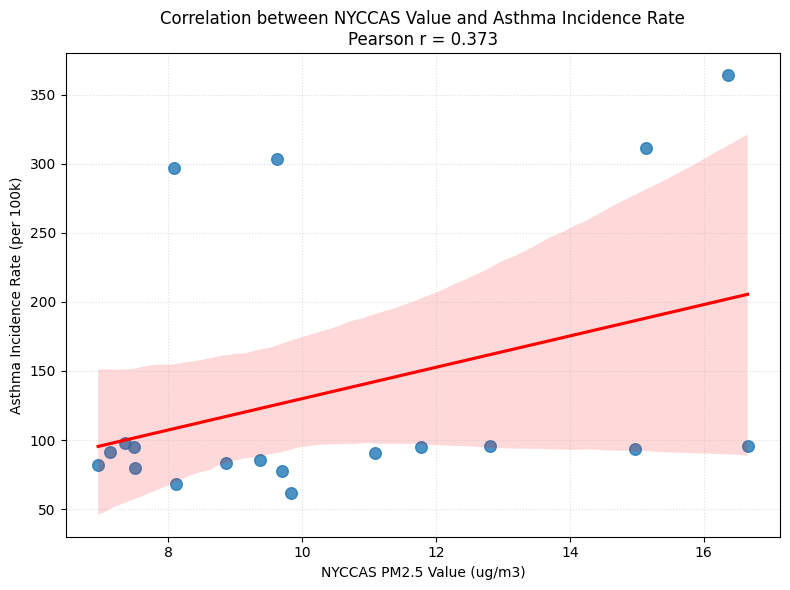

In [8]:
plot_df = merged[["Value", "asthma_incidence_rate", "Borough"]].dropna()

corr = plot_df["Value"].corr(plot_df["asthma_incidence_rate"])

plt.figure(figsize=(8, 6))
sns.regplot(
    data=plot_df,
    x="Value",
    y="asthma_incidence_rate",
    scatter_kws={"alpha": 0.8, "s": 70},
    line_kws={"color": "red"}
)

plt.title(f"Correlation between NYCCAS Value and Asthma Incidence Rate\nPearson r = {corr:.3f}")
plt.xlabel("NYCCAS PM2.5 Value (ug/m3)")
plt.ylabel("Asthma Incidence Rate (per 100k)")
plt.grid(True, linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

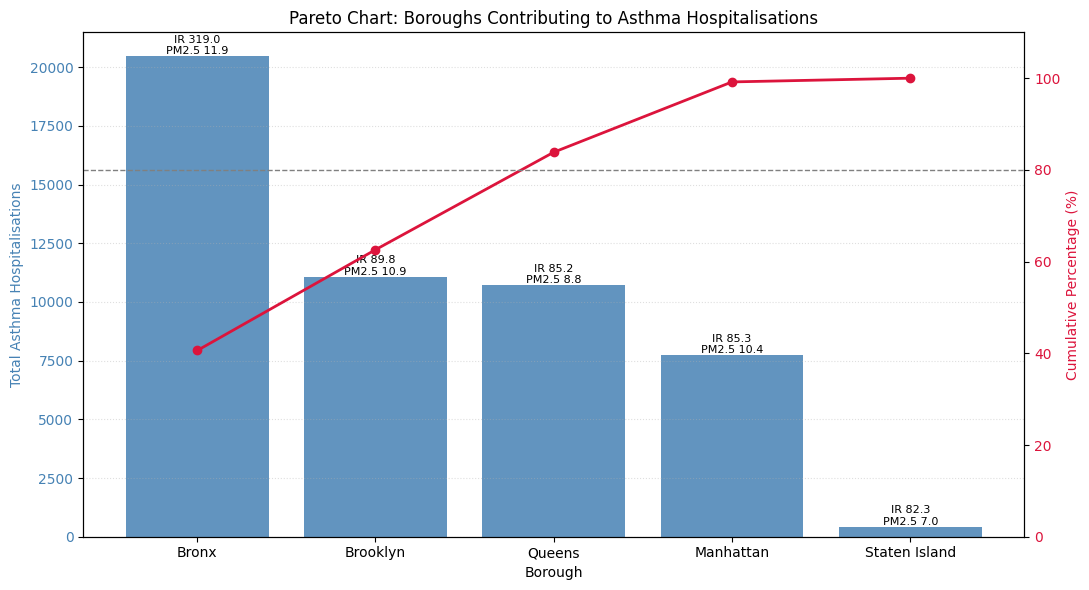

In [9]:
# Load and merge asthma and PM2.5 data
asthma_df = pd.read_csv("data_csv/merged_asthma_data.csv")
pm25_df = pd.read_csv("data_csv/NYCCAS-Yearly-Borough.csv")

asthma_df["Borough"] = asthma_df["Borough"].str.strip().str.title()
pm25_df["Borough"] = pm25_df["Borough"].str.strip().str.title()
pm25_df.rename(columns={"year": "Year"}, inplace=True)

pareto_df = asthma_df.merge(pm25_df[["Year", "Borough", "Value"]], on=["Year", "Borough"], how="inner")

# Borough summary for Pareto chart
borough_summary = (
    pareto_df.groupby("Borough", as_index=False)
    .agg(
        total_hospitalisations=("Asthma_Cases", "sum"),
        avg_incidence_rate=("asthma_incidence_rate", "mean"),
        avg_pm25=("Value", "mean"),
    )
    .sort_values("total_hospitalisations", ascending=False)
    .reset_index(drop=True)
)

borough_summary["cumulative_pct"] = (
    borough_summary["total_hospitalisations"].cumsum()
    / borough_summary["total_hospitalisations"].sum()
    * 100
)

# Pareto chart
fig, ax1 = plt.subplots(figsize=(11, 6))

bars = ax1.bar(
    borough_summary["Borough"],
    borough_summary["total_hospitalisations"],
    color="steelblue",
    alpha=0.85
)

ax1.set_xlabel("Borough")
ax1.set_ylabel("Total Asthma Hospitalisations", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_title("Pareto Chart: Boroughs Contributing to Asthma Hospitalisations")
ax1.grid(axis="y", linestyle=":", alpha=0.4)

# Annotate bars with incidence rate and PM2.5
for bar, inc, pm in zip(
    bars,
    borough_summary["avg_incidence_rate"],
    borough_summary["avg_pm25"]
):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"IR {inc:.1f}\nPM2.5 {pm:.1f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

ax2 = ax1.twinx()
ax2.plot(
    borough_summary["Borough"],
    borough_summary["cumulative_pct"],
    color="crimson",
    marker="o",
    linewidth=2
)
ax2.set_ylabel("Cumulative Percentage (%)", color="crimson")
ax2.tick_params(axis="y", labelcolor="crimson")
ax2.set_ylim(0, 110)
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

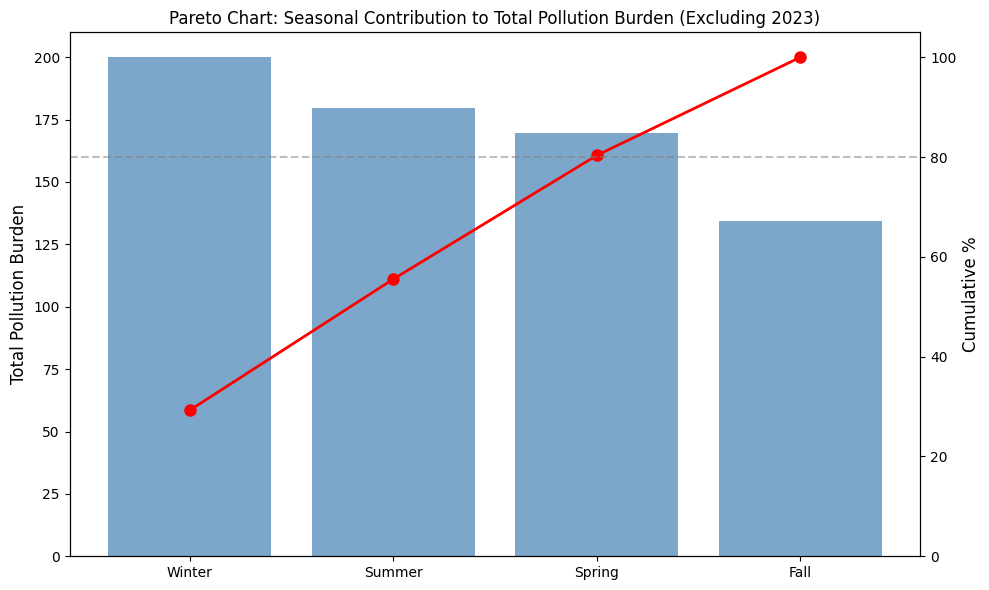

In [10]:
# Load data
seasonal = pd.read_csv('data_csv/NYCCAS-Seasonal-Borough.csv')

# Exclude 2023
seasonal = seasonal[seasonal['Year'] != 2023]

# Calculate seasonal contributions
seasonal_totals = seasonal.groupby('Season')['Value'].sum().sort_values(ascending=False)
cumulative_pct = (seasonal_totals.cumsum() / seasonal_totals.sum() * 100)

# Create Pareto chart
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart
ax1.bar(range(len(seasonal_totals)), seasonal_totals.values, color='steelblue', alpha=0.7)
ax1.set_ylabel('Total Pollution Burden', fontsize=12)
ax1.set_xticks(range(len(seasonal_totals)))
ax1.set_xticklabels(seasonal_totals.index)

# Cumulative line
ax2 = ax1.twinx()
ax2.plot(range(len(seasonal_totals)), cumulative_pct.values, 'ro-', linewidth=2, markersize=8)
ax2.set_ylabel('Cumulative %', fontsize=12)
ax2.set_ylim([0, 105])
ax2.axhline(y=80, color='gray', linestyle='--', alpha=0.5, label='80% threshold')

plt.title('Pareto Chart: Seasonal Contribution to Total Pollution Burden (Excluding 2023)')
plt.tight_layout()
plt.show()